# Статистический анализ двух бинарных выборок

## 📊 Условие задачи

### Исходные данные:
- **Две бинарные выборки** с вероятностями успеха:
  - $p_1 = 0.35$ (первая выборка)
  - $p_2 = 0.40$ (вторая выборка)
- **Уровень значимости**: $\alpha = 0.05$ (p-value)
- **Минимальный детектируемый эффект (MDE)**: $\delta = |p_2 - p_1| = 0.05$

### Поставленные задачи:

#### 1. 📈 Определение минимального размера выборки
**Цель**: Найти минимальное количество элементов $n$ в каждой выборке, необходимое для детекции MDE с заданной мощностью теста ($1 - \beta = 0.8$).

**Формула для расчета**:
$$
n = \frac{(z_{1-\alpha/2} \cdot \sqrt{2 \cdot \bar{p} \cdot (1-\bar{p})} + z_{1-\beta} \cdot \sqrt{p_1(1-p_1) + p_2(1-p_2)})^2}{(p_1 - p_2)^2}
$$

где:
- $\bar{p} = \frac{p_1 + p_2}{2}$ - объединенная пропорция
- $z_{1-\alpha/2}$ - квантиль нормального распределения для двустороннего теста
- $z_{1-\beta}$ - квантиль нормального распределения для мощности теста

#### 2. 🔄 Преобразование распределений через ЦПТ
**Цель**: Используя Центральную Предельную Теорему (ЦПТ), преобразовать биномиальные распределения к нормальным.

**Формулы преобразования**:
- Для выборки размера $n$ с вероятностью $p$:
  $$
  \text{Среднее: } \mu = p
  $$
  $$
  \text{Стандартное отклонение: } \sigma = \sqrt{\frac{p(1-p)}{n}}
  $$
- Получаем нормальные распределения:
  - Первая выборка: $N(\mu_1, \sigma_1)$
  - Вторая выборка: $N(\mu_2, \sigma_2)$

#### 3. 📊 Визуализация распределений и ошибок
**Требуется построить два графика**:

**График 1**: Двусторонняя альтернатива
- Распределения обеих выборок
- Критические области для ошибки I рода ($\alpha$)
- Область ошибки II рода ($\beta$)

**График 2**: Односторонняя альтернатива ($p_1 > p_2$)
- Распределения обеих выборок  
- Односторонние критические области
- Соответствующие области ошибок

**Обозначения на графиках**:
- 🟦 **Синяя область** - Ошибка I рода (вероятность $\alpha$)
- 🟥 **Красная область** - Ошибка II рода (вероятность $\beta$)
- 📍 **Вертикальные линии** - Критические значения и средние

#### 4. 📐 Расчет доверительных интервалов
**Цель**: Построить $95\%$ доверительные интервалы для средних значений обеих выборок.

**Формула доверительного интервала**:
$$
CI = \hat{p} \pm z_{1-\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

где:
- $\hat{p}$ - выборочная пропорция
- $z_{1-\alpha/2}$ - квантиль стандартного нормального распределения

### 🎯 Ожидаемые результаты:

1. **Числовой результат**: Минимальный размер выборки $n$
2. **Параметры распределений**: $\mu_1, \sigma_1, \mu_2, \sigma_2$
3. **Визуализация**: Два графика с областями статистических ошибок
4. **Интервальные оценки**: Доверительные интервалы для $p_1$ и $p_2$

### 📈 Статистические гипотезы:

**Для двустороннего теста**:
$$
H_0: p_1 = p_2
$$
$$
H_1: p_1 \neq p_2
$$

**Для одностороннего теста**:
$$
H_0: p_1 \leq p_2$$

$$H_1: p_1 > p_2
$$

АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК (С НЕРАВНЫМИ РАЗМЕРАМИ)

Вероятность в группе 1: 0.35
Вероятность в группе 2: 0.4
Уровень значимости (p-value): 0.05
Мощность теста: 0.8
------------------------------------------------------------
1. МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):

   n₁ = n₂ = 1471 элементов в каждой группе

2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:

   РАВНЫЕ ВЫБОРКИ (n=1471):

     Группа 1: N(μ=0.3500, σ=0.0124)
     Группа 2: N(μ=0.4000, σ=0.0128)

   НЕРАВНЫЕ ВЫБОРКИ (n₁=735, n₂=7350):

     Группа 1: N(μ=0.3500, σ=0.0176)
     Группа 2: N(μ=0.4000, σ=0.0057)

3. Двусторонняя альтернатива



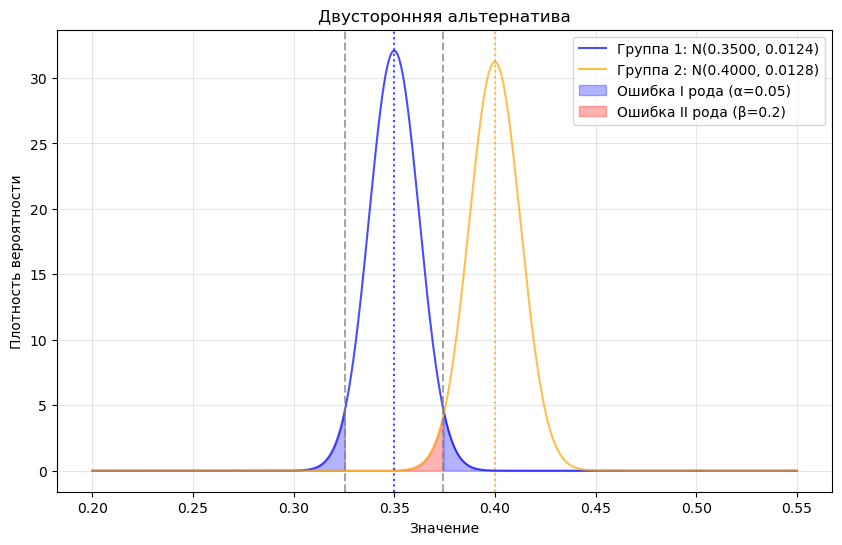

Односторонняя альтернатива



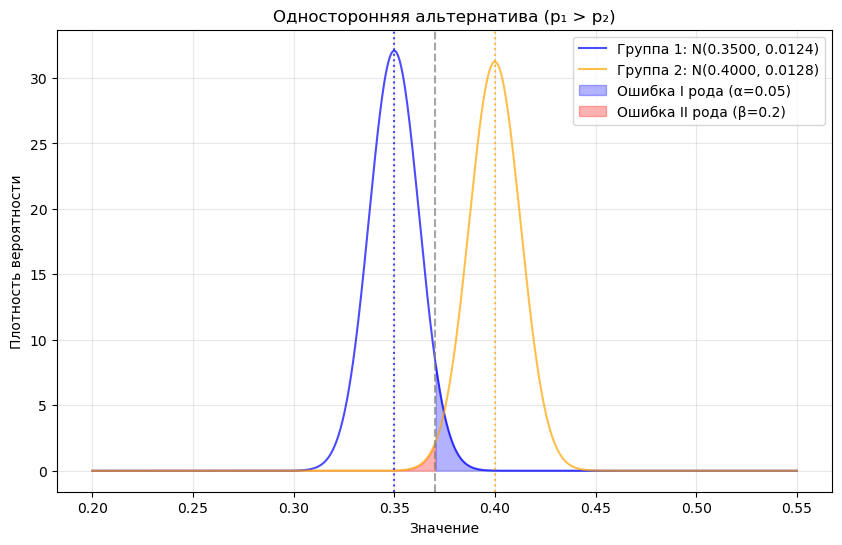

4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):

   РАВНЫЕ ВЫБОРКИ:

     Группа 1: [0.3256, 0.3744] (ширина: 0.0487)
     Группа 2: [0.3750, 0.4250] (ширина: 0.0501)

   НЕРАВНЫЕ ВЫБОРКИ:

     Группа 1: [0.3155, 0.3845] (ширина: 0.0690)
     Группа 2: [0.3888, 0.4112] (ширина: 0.0224)


In [6]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ====================
# ПАРАМЕТРЫ
# ====================
p1 = 0.35
p2 = 0.40
alpha = 0.05
beta = 0.20
delta = abs(p2 - p1)
power = 1 - beta

# ====================
# 1. МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ
# ====================
z_alpha = stats.norm.ppf(1 - alpha/2)
z_beta = stats.norm.ppf(power)
p_bar = (p1 + p2) / 2

numerator = (z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) + 
             z_beta * np.sqrt(p1*(1-p1) + p2*(1-p2)))**2
n = int(np.ceil(numerator / delta**2))

# ====================
# 2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ
# ====================
def normal_params(p, n):
    mu = p
    sigma = np.sqrt(p * (1 - p) / n)
    return mu, sigma

mu1, sigma1 = normal_params(p1, n)
mu2, sigma2 = normal_params(p2, n)

# Для неравных выборок
n1_unequal, n2_unequal = 735, 7350
mu1_u, sigma1_u = normal_params(p1, n1_unequal)
mu2_u, sigma2_u = normal_params(p2, n2_unequal)

# ====================
# 3. ВИЗУАЛИЗАЦИЯ
# ====================
def plot_distributions(two_sided=True):
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.linspace(0.2, 0.55, 1000)
    
    # Распределения
    y1 = stats.norm.pdf(x, mu1, sigma1)
    y2 = stats.norm.pdf(x, mu2, sigma2)
    ax.plot(x, y1, label=f'Группа 1: N({mu1:.4f}, {sigma1:.4f})', color='blue', alpha=0.7)
    ax.plot(x, y2, label=f'Группа 2: N({mu2:.4f}, {sigma2:.4f})', color='orange', alpha=0.7)
    
    # Критические области
    if two_sided:
        crit_left = stats.norm.ppf(alpha/2, mu1, sigma1)
        crit_right = stats.norm.ppf(1 - alpha/2, mu1, sigma1)
        
        # Ошибка I рода (синяя)
        x_alpha_left = x[x <= crit_left]
        x_alpha_right = x[x >= crit_right]
        ax.fill_between(x_alpha_left, stats.norm.pdf(x_alpha_left, mu1, sigma1), 
                        alpha=0.3, color='blue', label=f'Ошибка I рода (α={alpha})')
        ax.fill_between(x_alpha_right, stats.norm.pdf(x_alpha_right, mu1, sigma1), 
                        alpha=0.3, color='blue')
        
        # Ошибка II рода (красная)
        x_beta = x[(x > crit_left) & (x < crit_right)]
        ax.fill_between(x_beta, stats.norm.pdf(x_beta, mu2, sigma2), 
                        alpha=0.3, color='red', label=f'Ошибка II рода (β={beta})')
        
        # Вертикальные линии
        ax.axvline(crit_left, color='gray', linestyle='--', alpha=0.7)
        ax.axvline(crit_right, color='gray', linestyle='--', alpha=0.7)
        ax.axvline(mu1, color='blue', linestyle=':', alpha=0.7)
        ax.axvline(mu2, color='orange', linestyle=':', alpha=0.7)
        
        title = 'Двусторонняя альтернатива'
    else:
        crit = stats.norm.ppf(1 - alpha, mu1, sigma1)
        
        # Ошибка I рода
        x_alpha = x[x >= crit]
        ax.fill_between(x_alpha, stats.norm.pdf(x_alpha, mu1, sigma1), 
                        alpha=0.3, color='blue', label=f'Ошибка I рода (α={alpha})')
        
        # Ошибка II рода
        x_beta = x[x < crit]
        ax.fill_between(x_beta, stats.norm.pdf(x_beta, mu2, sigma2), 
                        alpha=0.3, color='red', label=f'Ошибка II рода (β={beta})')
        
        ax.axvline(crit, color='gray', linestyle='--', alpha=0.7)
        ax.axvline(mu1, color='blue', linestyle=':', alpha=0.7)
        ax.axvline(mu2, color='orange', linestyle=':', alpha=0.7)
        
        title = 'Односторонняя альтернатива (p₁ > p₂)'
    
    ax.set_xlabel('Значение')
    ax.set_ylabel('Плотность вероятности')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

# ====================
# 4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ
# ====================
def confidence_interval(p, n, alpha=0.05):
    z = stats.norm.ppf(1 - alpha/2)
    se = np.sqrt(p * (1 - p) / n)
    lower = p - z * se
    upper = p + z * se
    width = upper - lower
    return lower, upper, width

ci1_low, ci1_high, ci1_width = confidence_interval(p1, n)
ci2_low, ci2_high, ci2_width = confidence_interval(p2, n)

ci1_low_u, ci1_high_u, ci1_width_u = confidence_interval(p1, n1_unequal)
ci2_low_u, ci2_high_u, ci2_width_u = confidence_interval(p2, n2_unequal)

# ====================
# ВЫВОД РЕЗУЛЬТАТОВ
# ====================
print("="*60)
print("АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК (С НЕРАВНЫМИ РАЗМЕРАМИ)")
print("="*60)
print(f"\nВероятность в группе 1: {p1}")
print(f"Вероятность в группе 2: {p2}")
print(f"Уровень значимости (p-value): {alpha}")
print(f"Мощность теста: {power}")
print("-"*60)
print("1. МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):\n")
print(f"   n₁ = n₂ = {n} элементов в каждой группе\n")
print("2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:\n")
print("   РАВНЫЕ ВЫБОРКИ (n={}):\n".format(n))
print(f"     Группа 1: N(μ={mu1:.4f}, σ={sigma1:.4f})")
print(f"     Группа 2: N(μ={mu2:.4f}, σ={sigma2:.4f})\n")
print("   НЕРАВНЫЕ ВЫБОРКИ (n₁={}, n₂={}):\n".format(n1_unequal, n2_unequal))
print(f"     Группа 1: N(μ={mu1_u:.4f}, σ={sigma1_u:.4f})")
print(f"     Группа 2: N(μ={mu2_u:.4f}, σ={sigma2_u:.4f})\n")
print("3. Двусторонняя альтернатива\n")
plot_distributions(two_sided=True)
print("Односторонняя альтернатива\n")
plot_distributions(two_sided=False)
print("4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):\n")
print("   РАВНЫЕ ВЫБОРКИ:\n")
print(f"     Группа 1: [{ci1_low:.4f}, {ci1_high:.4f}] (ширина: {ci1_width:.4f})")
print(f"     Группа 2: [{ci2_low:.4f}, {ci2_high:.4f}] (ширина: {ci2_width:.4f})\n")
print("   НЕРАВНЫЕ ВЫБОРКИ:\n")
print(f"     Группа 1: [{ci1_low_u:.4f}, {ci1_high_u:.4f}] (ширина: {ci1_width_u:.4f})")
print(f"     Группа 2: [{ci2_low_u:.4f}, {ci2_high_u:.4f}] (ширина: {ci2_width_u:.4f})")